Análisis de sentimientos en twitter (X)

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
from wordcloud import WordCloud

plt.style.use("ggplot")

In [30]:
plt.rcParams["figure.figsize"] = (10,6) # Configuración para visualizar de mejor manera el contenido de los tweets
pd.set_option("display.max_colwidth",200)

In [31]:
col = ["sentiment", "id", "date", "query", "user", "text"]
df = pd.read_csv("../Data/training.1600000.processed.noemoticon.csv",encoding="latin-1",names=col)


In [32]:
df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


In [33]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   sentiment  1600000 non-null  int64
 1   id         1600000 non-null  int64
 2   date       1600000 non-null  str  
 3   query      1600000 non-null  str  
 4   user       1600000 non-null  str  
 5   text       1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 256.9 MB
None


In [34]:
df["sentiment"].value_counts() #Veamos la distribución de "sentimiento" en los tweets de Training.

sentiment
0    800000
4    800000
Name: count, dtype: int64

In [35]:
df["sentiment"]=df["sentiment"].replace({0: -1, 4: 1}) # Convertimos las etiquetas originales 0 y 4 a -> -1 y 1 en training.

In [36]:
print(df["sentiment"].value_counts ()) # confirmamos que se cambio el 4 a 1.

sentiment
-1    800000
 1    800000
Name: count, dtype: int64


In [37]:
print(df["sentiment"].value_counts(normalize=True))

sentiment
-1    0.5
 1    0.5
Name: proportion, dtype: float64


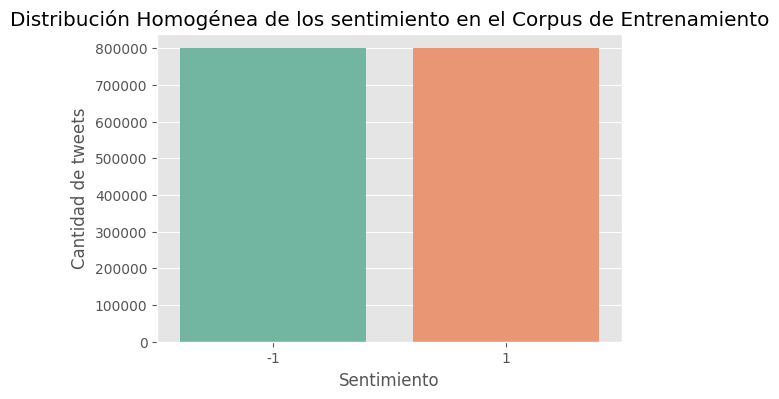

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="sentiment",palette="Set2")
plt.title("Distribución Homogénea de los sentimiento en el Corpus de Entrenamiento")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de tweets")
plt.show()

WordCloud con tweets sin limpieza

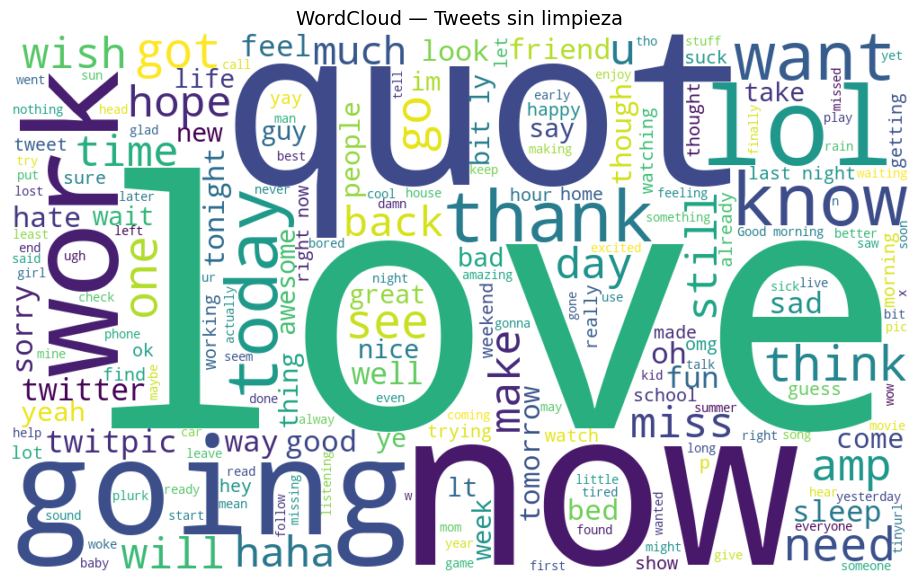

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

corpus = " ".join(df["text"])

wc = WordCloud(width=1000,height=600,background_color="white",colormap="viridis",  max_words=200).generate(corpus)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud — Tweets sin limpieza", fontsize=14)
plt.show()


Preprocesamiento

In [40]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [41]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

In [42]:
import html
# Construimos una función de limpiezan
def limpieza(texto):
    texto = html.unescape(texto)
    texto=texto.lower() #Minúsculas
    texto=re.sub(r"http\S+|www\S+", "", texto) #Eliminados URL
    texto = re.sub(r"@\w+", "", texto) #Eliminados Menciones 
    texto = re.sub(r"#", "", texto) #Eliminados el numeral # pero dejando el contenido de hashtag
    texto = re.sub(r"\d+", "", texto) #Eliminamos números
    texto = texto.translate(str.maketrans("", "", string.punctuation)) #Eliminamos signos de puntuación

    
    return texto

In [43]:
# Construimos una función para los stop_words
def remover_stopwords(texto):
    words = texto.split()
    words = [ w for w in words if w not in stop_words]

    return " ".join(words)

In [44]:
df["texto_limpio"] = df["text"].apply(limpieza).apply(remover_stopwords)


In [45]:
df[["text","texto_limpio"]].sample(10, random_state=42)

,text,texto_limpio
541200,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh hope ok
750,"@misstoriblack cool , i have no tweet apps for my razr 2",cool tweet apps razr
766711,"@TiannaChaos i know just family drama. its lame.hey next time u hang out with kim n u guys like have a sleepover or whatever, ill call u",know family drama lamehey next time u hang kim n u guys like sleepover whatever ill call u
285055,School email won't open and I have geography stuff on there to revise! *Stupid School* :'(,school email wont open geography stuff revise stupid school
705995,upper airways problem,upper airways problem
379611,Going to miss Pastor's sermon on Faith...,going miss pastors sermon faith
1189018,on lunch....dj should come eat with me,lunchdj come eat
667030,@piginthepoke oh why are you feeling like that?,oh feeling like
93541,gahh noo!peyton needs to live!this is horrible,gahh noopeyton needs livethis horrible
1097326,@mrstessyman thank you glad you like it! There is a product review bit on the site Enjoy knitting it!,thank glad like product review bit site enjoy knitting


In [46]:
df["texto_limpio"] = df["texto_limpio"].replace("", np.nan) # Identificamos tweets que quedaron vacíos luego de la limpieza.
valores_nulos = df["texto_limpio"].isna().sum() 

In [47]:
valores_nulos

np.int64(7309)

In [48]:
df = df.dropna(subset=["texto_limpio"]).reset_index(drop=True) #eliminamos las filas vacías

In [49]:
df.shape 

(1592691, 7)

In [50]:
#Calculemos las longitud de los textos que quedaron
df["long_caracteres"]=df["texto_limpio"].str.len()
df["conteo_palabras"] = df["texto_limpio"].apply(lambda x: len(x.split()))

In [51]:
df.groupby("sentiment")["long_caracteres"].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
-1,796337.0,43.785538,24.004403,1.0,24.0,40.0,61.0,330.0
1,796354.0,41.873863,23.757770,1.0,23.0,38.0,59.0,349.0


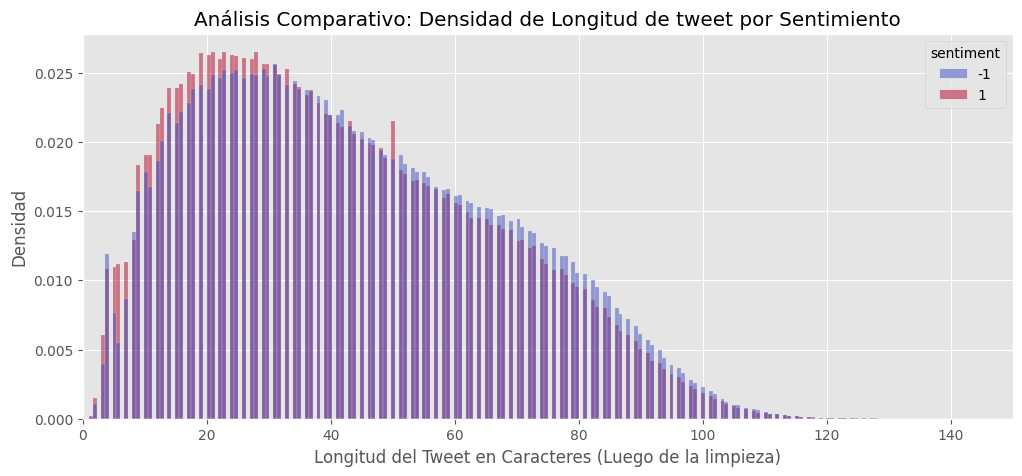

In [52]:
plt.figure(figsize=(12, 5))
sns.histplot(
    data=df,
    x="long_caracteres",
    hue="sentiment",
    stat="density",
    common_norm=False,
    palette="coolwarm",
)
plt.title("Análisis Comparativo: Densidad de Longitud de tweet por Sentimiento")
plt.xlabel("Longitud del Tweet en Caracteres (Luego de la limpieza)")
plt.ylabel("Densidad")
plt.xlim(0, 150)  
plt.show()

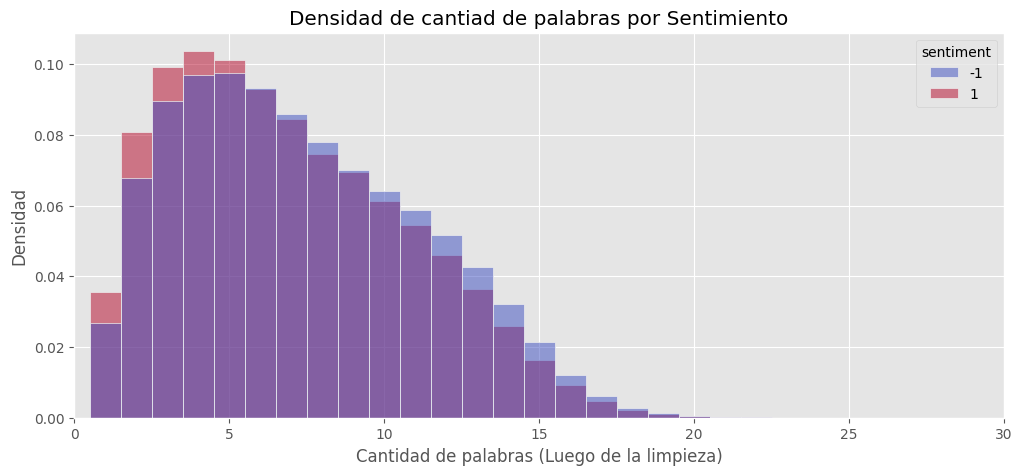

In [53]:
plt.figure(figsize=(12, 5))
sns.histplot(
    data=df,
    x="conteo_palabras",
    hue="sentiment",
    stat="density",
    common_norm=False,
    palette="coolwarm",
    discrete=True,
)
plt.title("Densidad de cantiad de palabras por Sentimiento")
plt.xlabel("Cantidad de palabras (Luego de la limpieza)")
plt.ylabel("Densidad")
plt.xlim(0, 30) 
plt.show()

WordCloud con tweets con limpieza

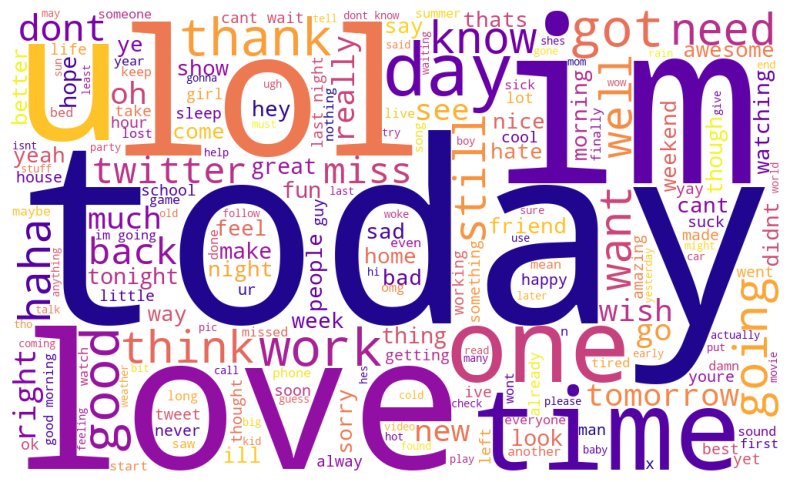

In [54]:
texto = " ".join(df["texto_limpio"].sample(100000, random_state=42))

wc= WordCloud( width=1000, height=600, background_color="white",max_words=200, colormap="plasma",).generate(texto)
plt.imshow(wc)
plt.axis("off")
plt.show()

In [55]:
# Guardamos el DataFrame limpio para el entrenmiento.
df.to_csv("../Preprocesamiento/training_limpio.csv", index=False, encoding="utf-8")